# Bildklassifikation für Qualitätskontrolle im Agrarbereich
## MobileNetV2 (Feature Extraction) + Random Forest (Klassifikation)

**Architektur:**
```
Bild → MobileNetV2 (eingefroren, kein Top) → 1280-dim Feature-Vektor → Random Forest → Klasse
```


## 1. Imports & Konfiguration

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import json
import sklearn
from zipfile import ZipFile
from tempfile import TemporaryDirectory
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)
print("scikit-learn Version:   ", sklearn.__version__)
print("GPU verfügbar:     ", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
scikit-learn Version:    1.9.1
GPU verfügbar:      []


In [ ]:
# Gleicher Datenpfad wie in eigenesCNN.ipynb.
# Relative Pfade beziehen sich auf das Arbeitsverzeichnis des Kernels.
DATA_DIR = Path("../../data/Apple_Data_bereinigt")
OUTPUT_DIR = Path("../../modelle/test")
# Auch beim Start aus dem Projektordner funktionieren die Pfade.
if not DATA_DIR.is_dir() and Path("data/Apple_Data_bereinigt").is_dir():
    DATA_DIR = Path("data/Apple_Data_bereinigt")
    OUTPUT_DIR = Path("modelle/test")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Datensatz fehlt: {DATA_DIR.resolve()}; Arbeitsverzeichnis: {Path.cwd()}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
tf.keras.utils.set_random_seed(SEED)

RF_PARAMS = dict(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced",
    criterion="gini",
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1,
)
FEATURE_PATH = OUTPUT_DIR / "mobilenet_v2_randomforest_features.npz"
MODEL_PATH = OUTPUT_DIR / "mobilenet_v2_randomforest.zip"
print("Daten:", DATA_DIR.resolve())
print("Modellpaket:", MODEL_PATH.resolve())


Daten: D:\apple_quality_classification\data\Apple_Data_bereinigt
Modellpaket: D:\apple_quality_classification\modelle\test\mobilenet_v2_randomforest.zip


## 2. Dataset laden und aufteilen (70 / 15 / 15)

Feste, nach Klassen geschichtete Dateilisten verhindern Ueberschneidungen zwischen den Splits. Die Aufteilung kann von aelteren Notebooks abweichen.

In [3]:
# Zuerst feste Dateilisten bilden, danach die Bild-Pipeline erstellen.
# So bleiben Validation und Test auch bei wiederholter Iteration getrennt.
index_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False,
)
class_names = index_ds.class_names
num_classes = len(class_names)
paths = np.array(index_ds.file_paths)
labels = np.array([class_names.index(Path(path).parent.name) for path in paths])
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.3, random_state=SEED, stratify=labels,
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels,
)
assert not (set(train_paths) & set(val_paths) or set(train_paths) & set(test_paths)
            or set(val_paths) & set(test_paths))

def load_image(path, label):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape((None, None, 3))
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

def make_dataset(image_paths, image_labels):
    return tf.data.Dataset.from_tensor_slices((image_paths, image_labels)).map(
        load_image, num_parallel_calls=tf.data.AUTOTUNE,
    ).batch(BATCH_SIZE)

train_ds_raw = make_dataset(train_paths, train_labels)
val_ds_raw = make_dataset(val_paths, val_labels)
test_ds_raw = make_dataset(test_paths, test_labels)
print("Klassen:", dict(enumerate(class_names)))
print("Bilder Train / Validation / Test:", len(train_paths), len(val_paths), len(test_paths))


Found 4751 files belonging to 2 classes.
Klassen: {0: 'Apple__Healthy', 1: 'Apple__Rotten'}
Bilder Train / Validation / Test: 3325 713 713


## 3. Data Augmentation

Nur für Training – Val/Test erhalten **keine** Augmentation.  
Identisch zum ursprünglichen Notebook.

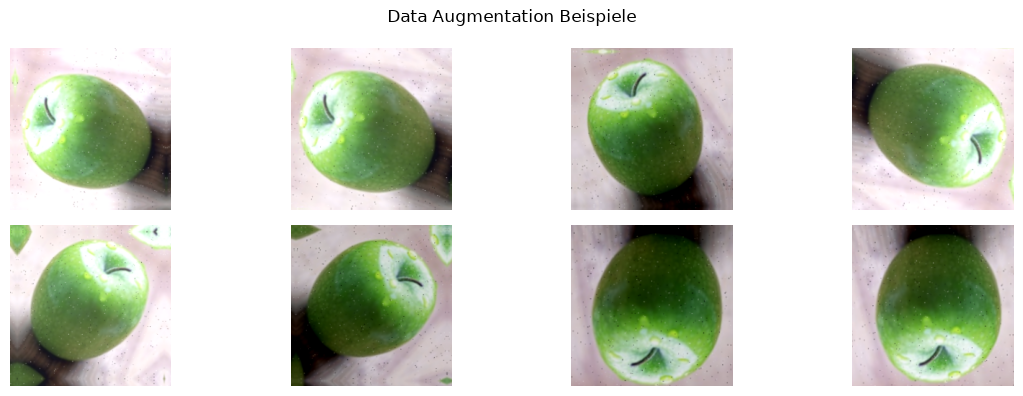

In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.1),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE

# Augmentation-Vorschau
sample_images, _ = next(iter(train_ds_raw))
plt.figure(figsize=(12, 4))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    aug_img = data_augmentation(tf.expand_dims(sample_images[0], 0), training=True)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.axis("off")
plt.suptitle("Data Augmentation Beispiele")
plt.tight_layout()
plt.show()


In [5]:
# Pipeline optimieren — Augmentation nur auf Training anwenden
train_ds = train_ds_raw.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)

val_ds  = val_ds_raw.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)


## 4. MobileNetV2 als Feature Extractor aufbauen

Der Dense-Head (256 Neuronen + Softmax) wird **entfernt**.  
Stattdessen gibt `GlobalAveragePooling2D` einen **1280-dimensionalen Feature-Vektor** pro Bild aus.  
Dieser Vektor ist der Input für Random Forest.

```
MobileNetV2 (eingefroren) → GlobalAveragePooling2D → (batch, 1280)
```

In [6]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,       # letzten Dense-Layer weglassen
    weights="imagenet",
)
base_model.trainable = False  # eingefroren — nur Feature Extraktion

feature_extractor = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(scale=1./127.5, offset=-1.0, name="mobilenet_preprocess"),
    base_model,
    layers.GlobalAveragePooling2D(),   # → (batch, 1280)
], name="MobileNetV2_FeatureExtractor")

feature_extractor.summary()


Model: "MobileNetV2_FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_preprocess            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Features extrahieren

Pro Trainingsbild wird eine augmentierte Variante extrahiert. Validation und Test bleiben ohne Augmentation. Die Features werden bei jedem Lauf neu erzeugt und separat gespeichert; ein alter XGBoost-Cache wird nicht uebernommen.

In [7]:
def extract_features(dataset, model, split_name=""):
    """Schickt alle Batches durch den Feature Extractor und sammelt Labels."""
    features, labels = [], []
    total = dataset.cardinality().numpy()
    for i, (images, lbls) in enumerate(dataset):
        feats = model(images, training=False)
        features.append(feats.numpy())
        labels.append(lbls.numpy())
        if (i + 1) % 10 == 0:
            print(f"  {split_name}: {i+1}/{total} Batches", end="\r")
    print()
    return np.concatenate(features), np.concatenate(labels)


In [8]:
X_train, y_train = extract_features(train_ds, feature_extractor, "Train")
X_val, y_val = extract_features(val_ds, feature_extractor, "Val")
X_test, y_test = extract_features(test_ds, feature_extractor, "Test")
np.savez_compressed(
    FEATURE_PATH, X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
    train_paths=train_paths, val_paths=val_paths, test_paths=test_paths,
    class_names=np.array(class_names),
)
print("Features gespeichert:", FEATURE_PATH)
print("Feature-Formen:", X_train.shape, X_val.shape, X_test.shape)


  Train: 100/104 Batches
  Val: 20/23 Batches
  Test: 20/23 Batches
Features gespeichert: ..\..\modelle\test\mobilenet_v2_randomforest_features.npz
Feature-Formen: (3325, 1280) (713, 1280) (713, 1280)


## 6. Random Forest trainieren

Random Forest erhält die 1280-dimensionalen Feature-Vektoren aus MobileNetV2 als Input.

In [9]:
clf = RandomForestClassifier(**RF_PARAMS)
clf.fit(X_train, y_train)
print(f"Validation Accuracy: {clf.score(X_val, y_val):.4f}")

# Beide Modellteile zusammen speichern; der Forest allein verarbeitet keine Bilder.
metadata = {
    "class_names": class_names,
    "image_size": list(IMG_SIZE),
    "preprocessing": "RGB 0..255; Rescaling auf [-1, 1] ist im Feature-Extractor enthalten",
    "rf_params": RF_PARAMS,
    "tensorflow_version": tf.__version__,
    "sklearn_version": sklearn.__version__,
    "seed": SEED,
}
with TemporaryDirectory() as temporary:
    folder = Path(temporary)
    feature_extractor.save(folder / "mobilenet_v2_extractor.keras")
    joblib.dump(clf, folder / "random_forest.joblib")
    (folder / "metadata.json").write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8",
    )
    with ZipFile(MODEL_PATH, "w") as bundle:
        for name in ("mobilenet_v2_extractor.keras", "random_forest.joblib", "metadata.json"):
            bundle.write(folder / name, arcname=name)
print("MobileNetV2 + Random Forest gespeichert:", MODEL_PATH.resolve())


Validation Accuracy: 0.9537


c:\Users\benke\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\core.py:172: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


MobileNetV2 + Random Forest gespeichert: D:\apple_quality_classification\modelle\test\mobilenet_v2_randomforest.zip


## 7. Evaluation auf dem Test-Set

In [15]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

test_acc = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names, labels=np.arange(num_classes), digits=4, zero_division=0))


Test Accuracy: 0.9551

                precision    recall  f1-score   support

Apple__Healthy     0.9182    0.9799    0.9481       298
 Apple__Rotten     0.9848    0.9373    0.9605       415

      accuracy                         0.9551       713
     macro avg     0.9515    0.9586    0.9543       713
  weighted avg     0.9570    0.9551    0.9553       713



## 8. Confusion Matrix

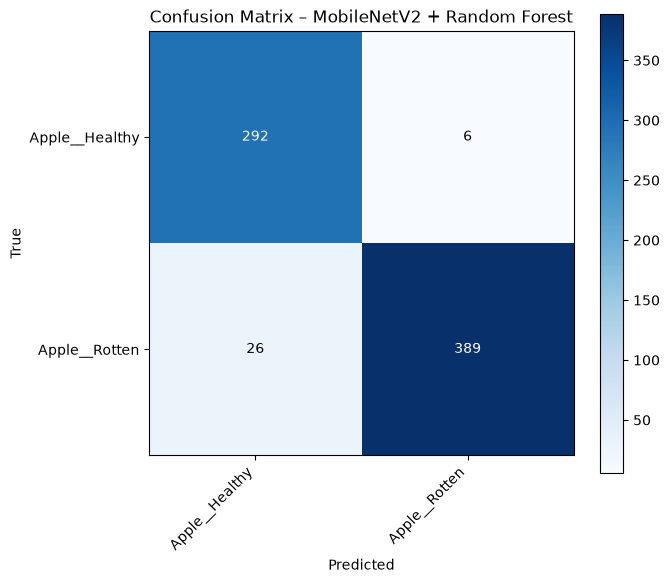

In [11]:
cm  = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes))
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – MobileNetV2 + Random Forest")
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_randomforest.png", dpi=150)
plt.show()


## 9. Random Forest Feature Importance

Zeigt, welche der 1280 MobileNetV2-Aktivierungen Random Forest am stärksten für die Klassifikation nutzt.

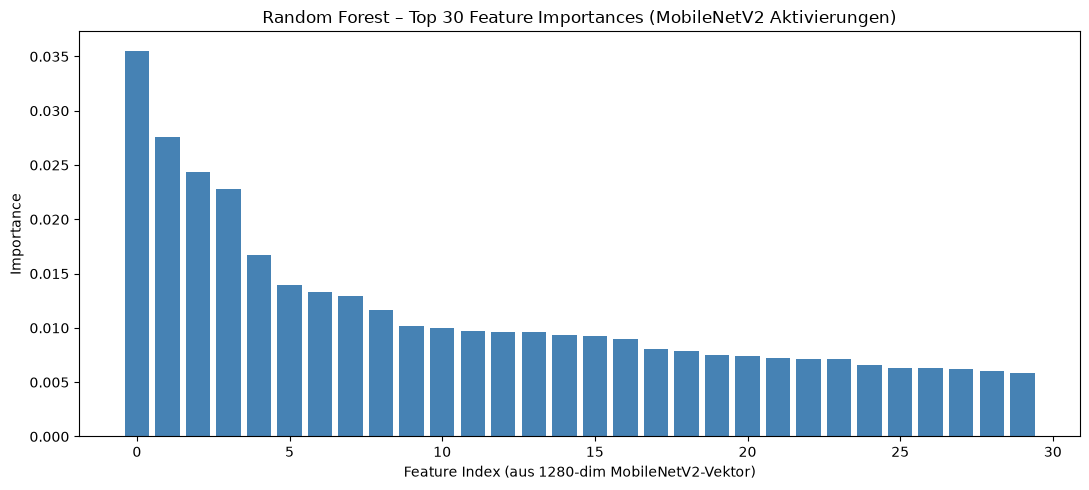

In [12]:
importance = clf.feature_importances_
top_idx    = np.argsort(importance)[-30:][::-1]

plt.figure(figsize=(11, 5))
plt.bar(range(30), importance[top_idx], color="steelblue")
plt.title("Random Forest – Top 30 Feature Importances (MobileNetV2 Aktivierungen)")
plt.xlabel("Feature Index (aus 1280-dim MobileNetV2-Vektor)")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_randomforest.png", dpi=150)
plt.show()


## 10. Einzelbild-Inferenz (für Produktivsystem)

Identische Schnittstelle wie im ursprünglichen MobileNetV2-Notebook.

In [13]:
def predict_single_image(image_path: str):
    """Klassifiziert ein einzelnes Bild mit MobileNetV2 + Random Forest."""
    img       = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)   # Batch-Dimension hinzufügen

    features      = feature_extractor(img_array, training=False).numpy()
    pred_label    = int(clf.predict(features)[0])
    probabilities = clf.predict_proba(features)[0]

    predicted_class = class_names[pred_label]
    confidence      = float(probabilities[pred_label])

    print(f"Klasse:      {predicted_class}")
    print(f"Konfidenz:   {confidence:.2%}")
    print(f"Alle Scores: { {c: f'{p:.2%}' for c, p in zip(class_names, probabilities)} }")

    return predicted_class, confidence

# Beispielaufruf:
# predicted_class, conf = predict_single_image("pfad/zum/bild.jpg")


## 11. Gespeicherte Kombination wieder laden

Das ZIP-Paket enthaelt den MobileNetV2-Extractor inklusive Vorverarbeitung, den Random Forest und die Klassenreihenfolge. Die folgende Zelle laedt beide Teile. Danach funktioniert predict_single_image(...) ohne erneutes Training. Nur eigene oder vertrauenswuerdige Modellpakete laden.


In [14]:
def load_model_bundle(model_path):
    with TemporaryDirectory() as temporary:
        folder = Path(temporary)
        with ZipFile(model_path, "r") as bundle:
            for name in ("mobilenet_v2_extractor.keras", "random_forest.joblib", "metadata.json"):
                (folder / name).write_bytes(bundle.read(name))
        extractor = tf.keras.models.load_model(folder / "mobilenet_v2_extractor.keras", compile=False)
        forest = joblib.load(folder / "random_forest.joblib")
        metadata = json.loads((folder / "metadata.json").read_text(encoding="utf-8"))
    return extractor, forest, metadata

feature_extractor, clf, saved_metadata = load_model_bundle(MODEL_PATH)
class_names = saved_metadata["class_names"]
IMG_SIZE = tuple(saved_metadata["image_size"])
print("Modellkombination geladen:", MODEL_PATH)
# predict_single_image("pfad/zum/apfelbild.jpg")


Modellkombination geladen: ..\..\modelle\test\mobilenet_v2_randomforest.zip
